# Seoul Bike Sharing Demand — CRISP-DM Project
**BMDS2003 Data Science**

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
%matplotlib inline

In [2]:
df = pd.read_csv("SeoulBikeData.csv")
display(df.head())

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## 3.0 Data Understanding

### 3.1 Dataset Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

### 3.2 Summary Statistics

In [4]:
summary_statistics = df.describe()
display(summary_statistics)

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


### 3.3 Missing Values and Duplicate Records

In [5]:
missing_values = df.isnull().sum()
print("Missing values for each variable:")
display(missing_values)
print("\nTotal missing values:", missing_values.sum())

Missing values for each variable:


Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64


Total missing values: 0


In [6]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [7]:
print(df.dtypes)

Date                             str
Rented Bike Count              int64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Seasons                          str
Holiday                          str
Functioning Day                  str
dtype: object


### 3.4 Target Variable Distribution

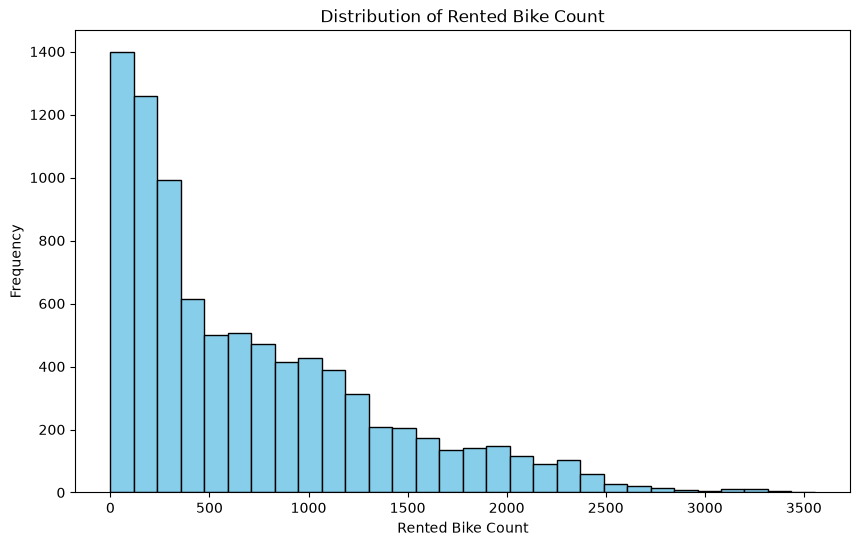

Skewness: 1.1534281773679014


In [8]:
plt.figure(figsize=(10, 6))
plt.hist(df["Rented Bike Count"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Rented Bike Count")
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")
plt.show()

print("Skewness:", df["Rented Bike Count"].skew())

### 3.5 Demand Patterns by Hour

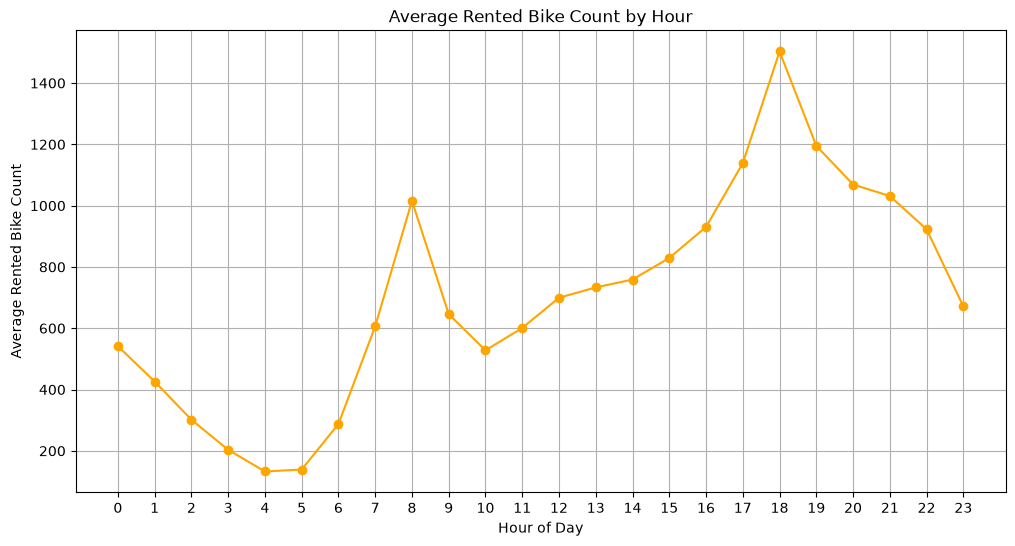

In [9]:
hourly_demand = df.groupby("Hour")["Rented Bike Count"].mean()

plt.figure(figsize=(12, 6))
plt.plot(hourly_demand.index, hourly_demand.values, marker="o", color="orange")
plt.title("Average Rented Bike Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rented Bike Count")
plt.xticks(range(24))
plt.grid(True)
plt.show()

### 3.6 Demand Patterns by Season

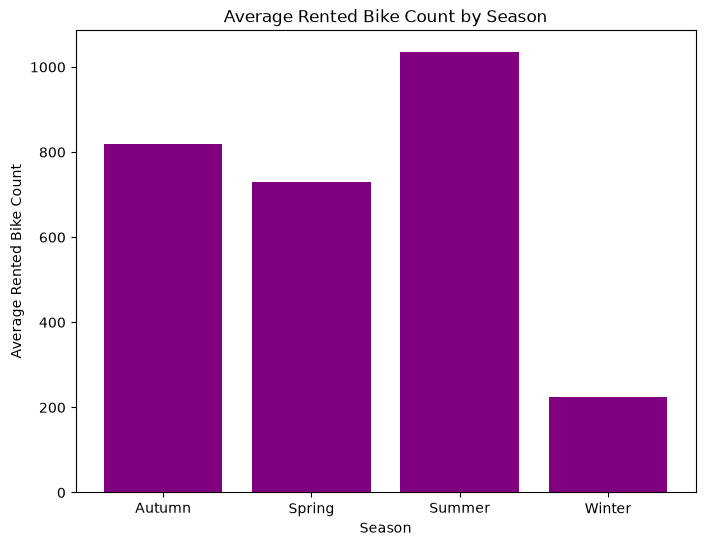

In [10]:
season_demand = df.groupby("Seasons")["Rented Bike Count"].mean()

plt.figure(figsize=(8, 6))
plt.bar(season_demand.index, season_demand.values, color="purple")
plt.title("Average Rented Bike Count by Season")
plt.xlabel("Season")
plt.ylabel("Average Rented Bike Count")
plt.show()

### 3.7 Functioning Day Check

In [11]:
print(df["Functioning Day"].value_counts())
print()
print(df.loc[df["Functioning Day"] == "No", "Rented Bike Count"].describe())

Functioning Day
Yes    8465
No      295
Name: count, dtype: int64

count    295.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Rented Bike Count, dtype: float64


**Observation:** All 295 rows where `Functioning Day == "No"` have `Rented Bike Count == 0`. On these days the system is closed, so there is no real demand to predict. These rows will be removed in Data Preparation (Section 4.1) since they do not reflect genuine demand and would artificially inflate model performance (an "always predict 0 when closed" pattern is trivial).

### 3.8 Correlation Analysis

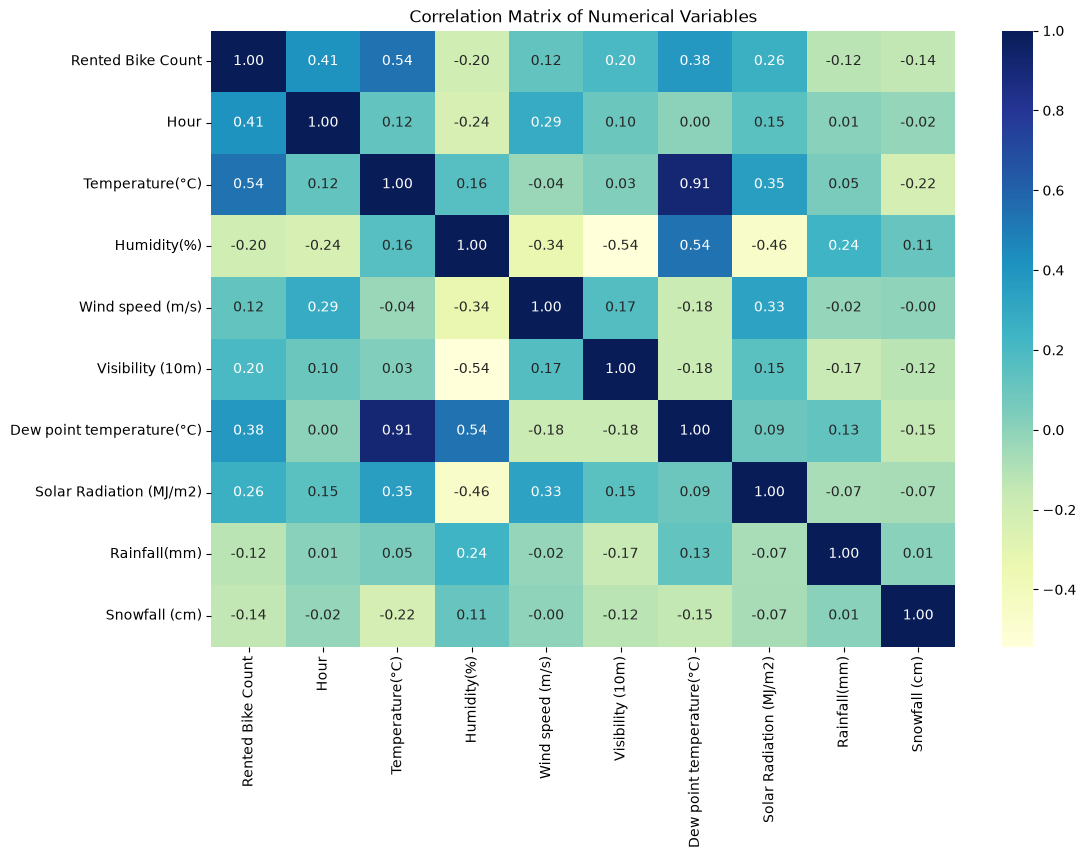

In [12]:
numerical_data = df.select_dtypes(include="number")
correlation_matrix = numerical_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [13]:
target_correlation = correlation_matrix["Rented Bike Count"].sort_values(ascending=False)
print("Correlation with Rented Bike Count:")
display(target_correlation)

Correlation with Rented Bike Count:


Rented Bike Count            1.000000
Temperature(°C)              0.538558
Hour                         0.410257
Dew point temperature(°C)    0.379788
Solar Radiation (MJ/m2)      0.261837
Visibility (10m)             0.199280
Wind speed (m/s)             0.121108
Rainfall(mm)                -0.123074
Snowfall (cm)               -0.141804
Humidity(%)                 -0.199780
Name: Rented Bike Count, dtype: float64

### 3.9 Temperature Distribution

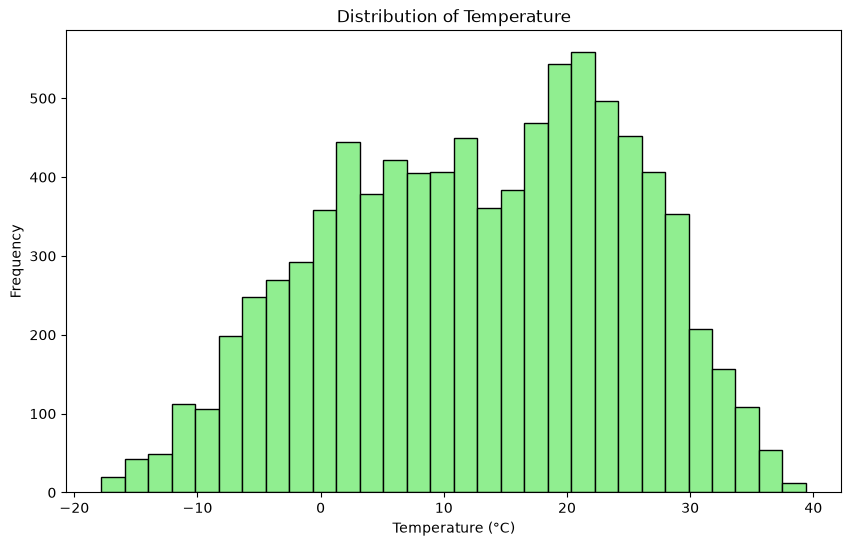

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(df["Temperature(°C)"], bins=30, color="lightgreen", edgecolor="black")
plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

## 4.0 Data Preparation

### 4.1 Remove Non-Functioning Day Records

In [15]:
print("Rows before removing non-functioning days:", df.shape)

df = df[df["Functioning Day"] == "Yes"].reset_index(drop=True)

print("Rows after removing non-functioning days:", df.shape)

Rows before removing non-functioning days: (8760, 14)
Rows after removing non-functioning days: (8465, 14)


### 4.2 Convert Date to Datetime

In [16]:
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
print(df["Date"].dtype)
display(df[["Date", "Hour"]].head())

datetime64[us]


,Date,Hour
0,2017-12-01,0
1,2017-12-01,1
2,2017-12-01,2
3,2017-12-01,3
4,2017-12-01,4


### 4.3 Feature Engineering from Date

In [17]:
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

display(df[["Date", "DayOfWeek", "Month", "IsWeekend"]].head())

,Date,DayOfWeek,Month,IsWeekend
0,2017-12-01,4,12,0
1,2017-12-01,4,12,0
2,2017-12-01,4,12,0
3,2017-12-01,4,12,0
4,2017-12-01,4,12,0


### 4.4 Identify Feature Types
Separate the categorical and numerical features that will be used for modelling.

In [18]:
categorical_features = [
    "Seasons",
    "Holiday",
    "Functioning Day"
]

numerical_features = [
    "Hour",
    "Temperature(°C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Dew point temperature(°C)",
    "Solar Radiation (MJ/m2)",
    "Rainfall(mm)",
    "Snowfall (cm)",
    "DayOfWeek",
    "Month",
    "IsWeekend"
]

print("Categorical features:")
print(categorical_features)
print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Seasons', 'Holiday', 'Functioning Day']

Numerical features:
['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'DayOfWeek', 'Month', 'IsWeekend']


### 4.5 Outlier Detection on Target Variable

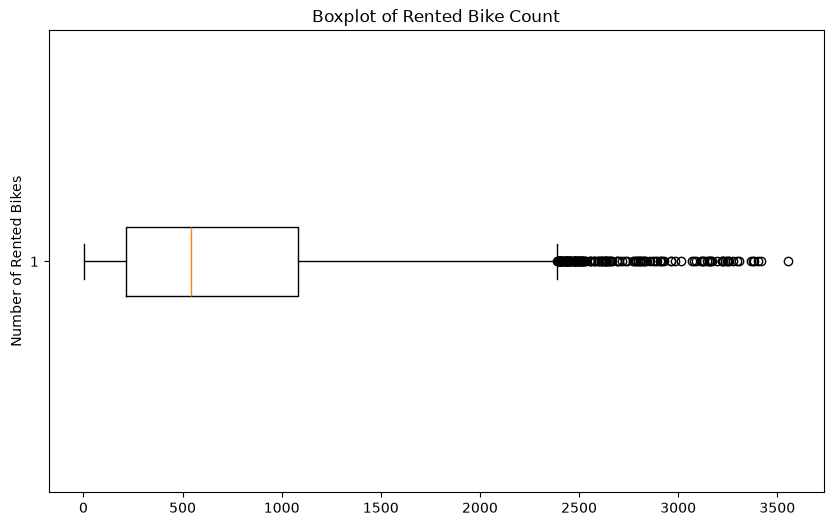

In [19]:
plt.figure(figsize=(10, 6))
# orientation="horizontal" replaces the deprecated vert=False argument
plt.boxplot(df["Rented Bike Count"], orientation="horizontal")
plt.title("Boxplot of Rented Bike Count")
plt.ylabel("Number of Rented Bikes")
plt.show()

In [20]:
Q1 = df["Rented Bike Count"].quantile(0.25)
Q3 = df["Rented Bike Count"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Rented Bike Count"] < lower_bound) |
    (df["Rented Bike Count"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

Q1: 214.0
Q3: 1084.0
IQR: 870.0
Lower Bound: -1091.0
Upper Bound: 2389.0
Number of potential outliers: 152


### 4.6 Define Features (X) and Target (y)

In [21]:
df = df.sort_values(["Date", "Hour"]).reset_index(drop=True)

y = df["Rented Bike Count"]
X = df[
    [
        "Hour",
        "Temperature(°C)",
        "Humidity(%)",
        "Wind speed (m/s)",
        "Visibility (10m)",
        "Dew point temperature(°C)",
        "Solar Radiation (MJ/m2)",
        "Rainfall(mm)",
        "Snowfall (cm)",
        "Seasons",
        "Holiday",
        "Functioning Day",
        "DayOfWeek",
        "Month",
        "IsWeekend"
    ]
]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8465, 15)
y shape: (8465,)


### 4.7 Train-Test Split

In [22]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6772, 15)
Testing data: (1693, 15)


### 4.8 Preprocessing Pipeline

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing setup completed.")

Preprocessing setup completed.


In [24]:
X_train_transformed = preprocessor.fit_transform(X_train)
print("Transformed training data shape:", X_train_transformed.shape)

Transformed training data shape: (6772, 16)


---

## 5.0 Modelling

### Preprocessing for Tree-Based Models

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Tree-based preprocessing setup completed.")

Tree-based preprocessing setup completed.


### Model Evaluation Helper

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

def evaluate_model(model_name, y_train, y_train_pred, y_test, y_test_pred):
    return {
        "Model": model_name,
        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Train RMSE": mean_squared_error(y_train, y_train_pred) ** 0.5,
        "Train R2": r2_score(y_train, y_train_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "Test RMSE": mean_squared_error(y_test, y_test_pred) ** 0.5,
        "Test R2": r2_score(y_test, y_test_pred)
    }

all_model_results = []

## 5.1 Linear Regression - Baseline Model

### Model Configuration & Parameter Setting

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

### Model Training

In [28]:
lr_final = lr_model
lr_final.fit(X_train, y_train)

print("Linear Regression training completed.")

lr_final

Linear Regression training completed.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Hour','Temperature(°C)','Humidity(%)',...,'DayOfWeek','Month', 'IsWeekend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

### Demand Prediction

In [29]:
lr_train_pred = lr_final.predict(X_train)
lr_test_pred = lr_final.predict(X_test)

print("Linear Regression predictions generated.")

Linear Regression predictions generated.


### Model Performance

In [30]:
lr_results = evaluate_model(
    "Linear Regression",
    y_train,
    lr_train_pred,
    y_test,
    lr_test_pred
)

lr_results_df = pd.DataFrame([lr_results]).round(3)
all_model_results.append(lr_results)

lr_results_df

,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Linear Regression,325.586,433.837,0.549,324.433,434.082,0.475


### Result Visualisation

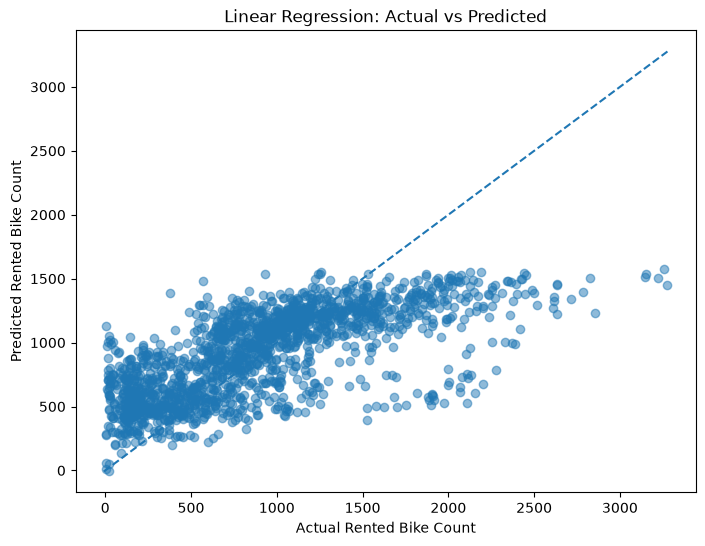

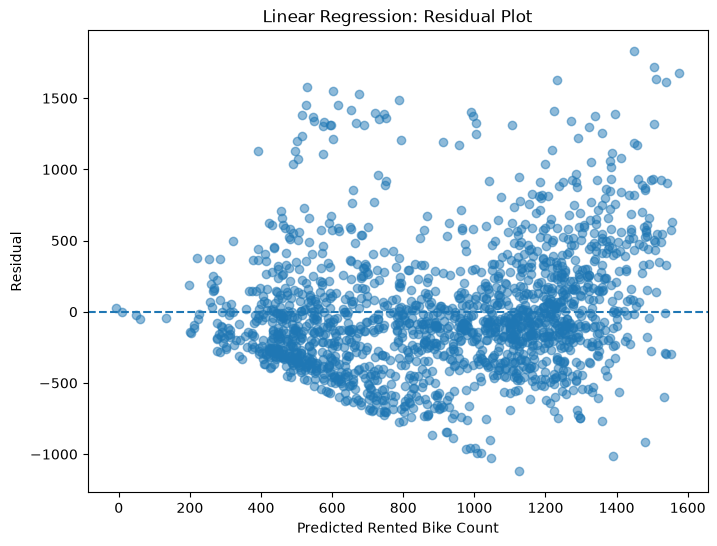

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, lr_test_pred, alpha=0.5)

min_value = min(y_test.min(), lr_test_pred.min())
max_value = max(y_test.max(), lr_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()


lr_residuals = y_test - lr_test_pred
plt.figure(figsize=(8, 6))
plt.scatter(
    lr_test_pred,
    lr_residuals,
    alpha=0.5
)
plt.axhline(
    y=0,
    linestyle="--"
)
plt.xlabel("Predicted Rented Bike Count")
plt.ylabel("Residual")
plt.title("Linear Regression: Residual Plot")
plt.show()

## 5.2 Decision Tree Regression

### Model Configuration & Parameter Setting

In [32]:
from sklearn.tree import DecisionTreeRegressor

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

tree_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

In [33]:
tree_param_grid = {
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}

tree_grid = GridSearchCV(
    tree_model,
    tree_param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print(tree_grid.best_params_)

{'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5}


### Model Training

In [34]:
tree_final = tree_grid.best_estimator_

print("Decision Tree training completed.")

tree_final

Decision Tree training completed.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Hour','Temperature(°C)','Humidity(%)',...,'DayOfWeek','Month', 'IsWeekend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

### Demand Prediction

In [35]:
tree_train_pred = tree_final.predict(X_train)
tree_test_pred = tree_final.predict(X_test)

print("Decision Tree predictions generated.")

Decision Tree predictions generated.


### Model Performance

In [36]:
tree_results = evaluate_model(
    "Decision Tree Regression",
    y_train,
    tree_train_pred,
    y_test,
    tree_test_pred
)

tree_results_df = pd.DataFrame([tree_results]).round(3)
all_model_results.append(tree_results)

tree_results_df

,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Decision Tree Regression,37.393,73.821,0.987,290.307,396.504,0.562


### Result Visualisation

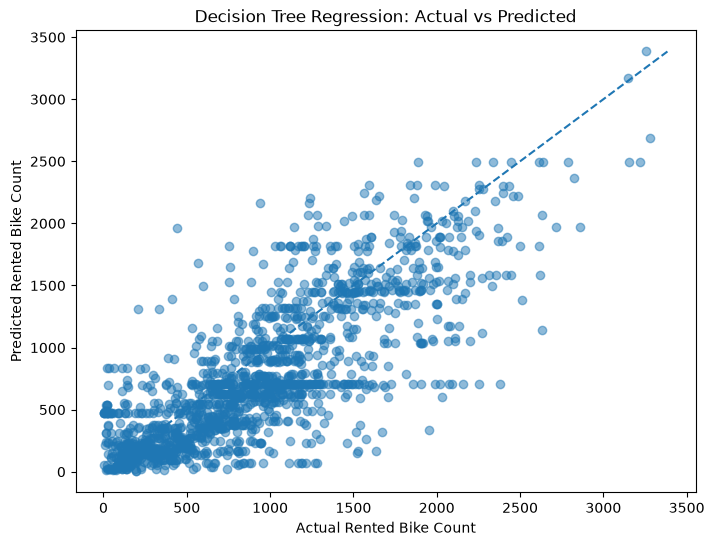

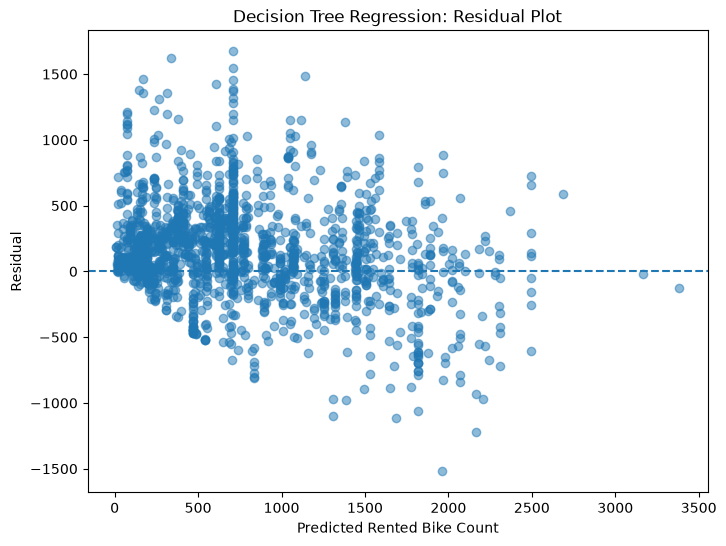

In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, tree_test_pred, alpha=0.5)

min_value = min(y_test.min(), tree_test_pred.min())
max_value = max(y_test.max(), tree_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Decision Tree Regression: Actual vs Predicted")

plt.show()


tree_residuals = y_test - tree_test_pred
plt.figure(figsize=(8, 6))
plt.scatter(
    tree_test_pred,
    tree_residuals,
    alpha=0.5
)
plt.axhline(
    y=0,
    linestyle="--"
)
plt.xlabel("Predicted Rented Bike Count")
plt.ylabel("Residual")
plt.title("Decision Tree Regression: Residual Plot")
plt.show()

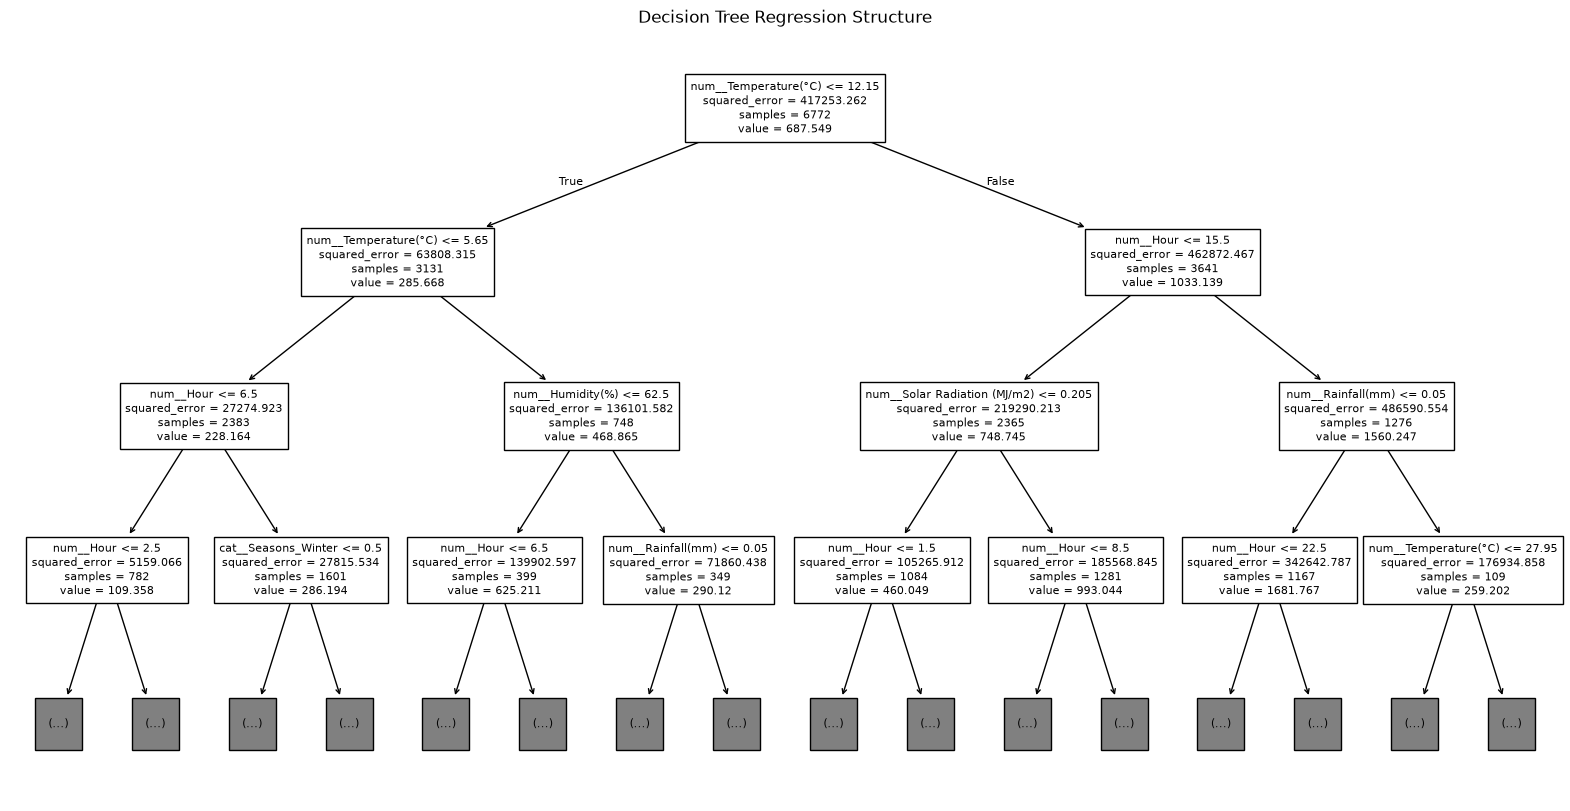

In [38]:
from sklearn.tree import plot_tree

tree_preprocessor_fitted = tree_final.named_steps["preprocessor"]
tree_regressor = tree_final.named_steps["model"]
feature_names = tree_preprocessor_fitted.get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    tree_regressor,
    feature_names=feature_names,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree Regression Structure")
plt.show()

## 5.3 Random Forest Regression

### Model Configuration & Parameter Setting

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [40]:
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": [1.0, "sqrt"]
}

rf_grid = GridSearchCV(
    rf_model,
    rf_param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print(rf_grid.best_params_)

{'model__max_depth': 20, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}


### Model Training

In [41]:
rf_model.fit(X_train, y_train)
rf_tuned = rf_grid.best_estimator_

rf_initial_rmse = mean_squared_error(y_test, rf_model.predict(X_test)) ** 0.5
rf_tuned_rmse = mean_squared_error(y_test, rf_tuned.predict(X_test)) ** 0.5

rf_final = rf_tuned if rf_tuned_rmse < rf_initial_rmse else rf_model

print("Random Forest training completed.")

rf_final

Random Forest training completed.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Hour','Temperature(°C)','Humidity(%)',...,'DayOfWeek','Month', 'IsWeekend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

### Demand Prediction

In [42]:
rf_train_pred = rf_final.predict(X_train)
rf_test_pred = rf_final.predict(X_test)

print("Random Forest predictions generated.")

Random Forest predictions generated.


### Model Performance

In [43]:
rf_results = evaluate_model(
    "Random Forest Regression",
    y_train,
    rf_train_pred,
    y_test,
    rf_test_pred
)

rf_results_df = pd.DataFrame([rf_results]).round(3)
all_model_results.append(rf_results)

rf_results_df

,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Random Forest Regression,41.05,73.286,0.987,224.953,321.427,0.712


### Result Visualisation

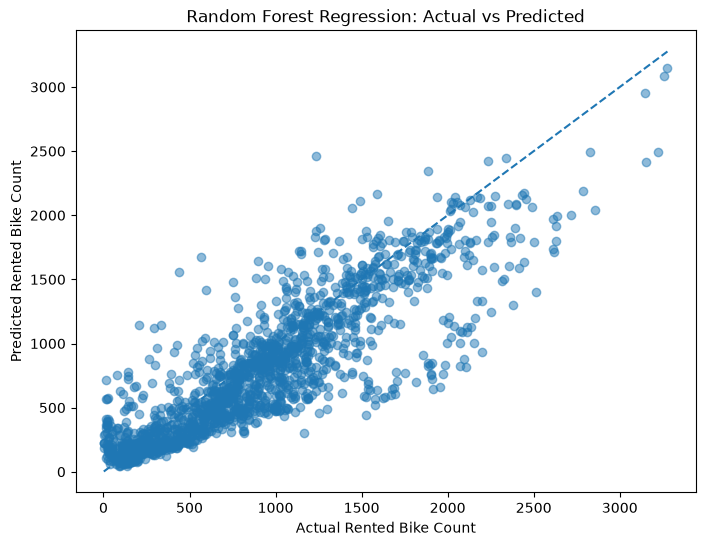

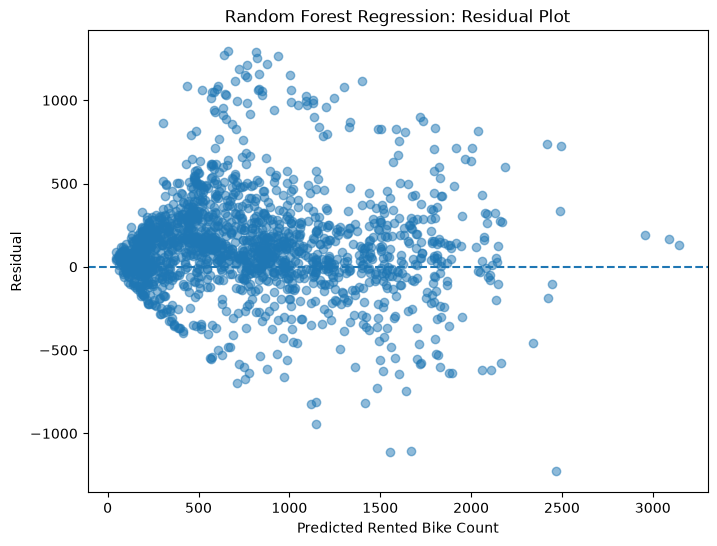

In [44]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_test_pred, alpha=0.5)

min_value = min(y_test.min(), rf_test_pred.min())
max_value = max(y_test.max(), rf_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Random Forest Regression: Actual vs Predicted")

plt.show()


rf_residuals = y_test - rf_test_pred
plt.figure(figsize=(8, 6))
plt.scatter(
    rf_test_pred,
    rf_residuals,
    alpha=0.5
)
plt.axhline(
    y=0,
    linestyle="--"
)
plt.xlabel("Predicted Rented Bike Count")
plt.ylabel("Residual")
plt.title("Random Forest Regression: Residual Plot")
plt.show()

## 5.4 Gradient Boosting Regression

### Model Configuration & Parameter Setting

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

gb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

gb_model = Pipeline(
    steps=[
        ("preprocessor", gb_preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)

In [46]:
gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5],
    "model__min_samples_leaf": [1, 5]
}

gb_grid = GridSearchCV(
    gb_model,
    gb_param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print(gb_grid.best_params_)

{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}


### Model Training

In [47]:
gb_final = gb_grid.best_estimator_

print("Gradient Boosting training completed.")

gb_final

Gradient Boosting training completed.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Hour','Temperature(°C)','Humidity(%)',...,'DayOfWeek','Month', 'IsWeekend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

### Demand Prediction

In [48]:
gb_train_pred = gb_final.predict(X_train)
gb_test_pred = gb_final.predict(X_test)

print("Gradient Boosting predictions generated.")

Gradient Boosting predictions generated.


### Model Performance

In [49]:
gb_results = evaluate_model(
    "Gradient Boosting Regression",
    y_train,
    gb_train_pred,
    y_test,
    gb_test_pred
)

gb_results_df = pd.DataFrame([gb_results]).round(3)
all_model_results.append(gb_results)

gb_results_df

,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Gradient Boosting Regression,111.05,172.471,0.929,249.156,344.921,0.669


### Result Visualisation

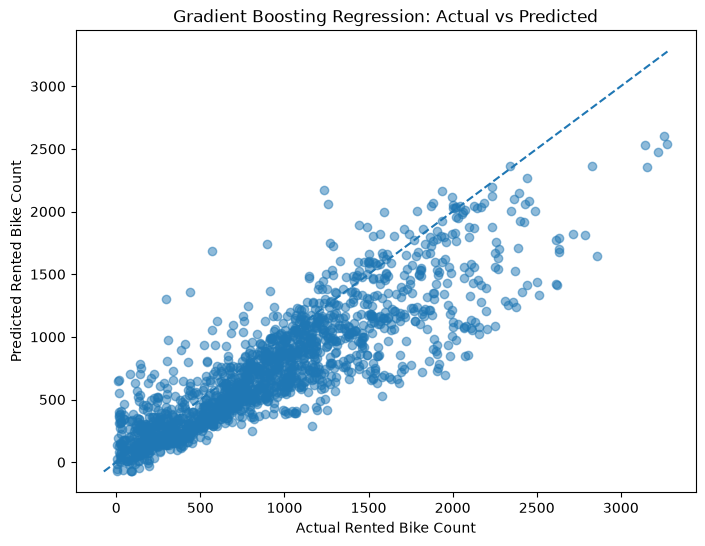

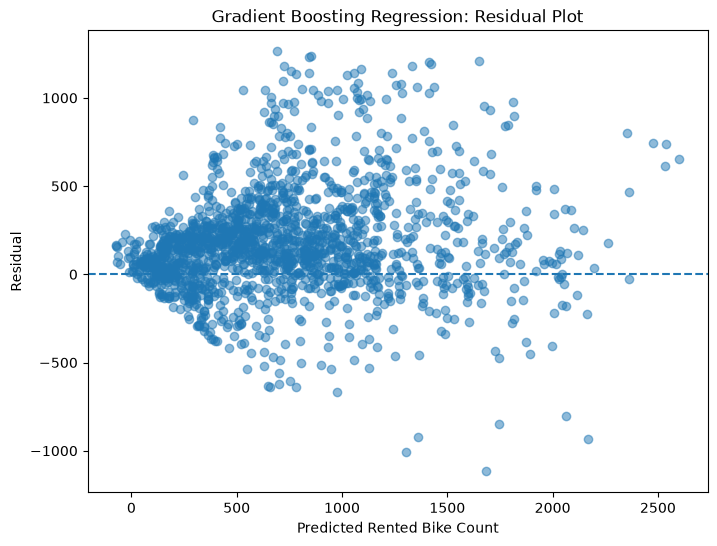

In [50]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, gb_test_pred, alpha=0.5)

min_value = min(y_test.min(), gb_test_pred.min())
max_value = max(y_test.max(), gb_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Gradient Boosting Regression: Actual vs Predicted")

plt.show()


gb_residuals = y_test - gb_test_pred
plt.figure(figsize=(8, 6))
plt.scatter(
    gb_test_pred,
    gb_residuals,
    alpha=0.5
)
plt.axhline(
    y=0,
    linestyle="--"
)
plt.xlabel("Predicted Rented Bike Count")
plt.ylabel("Residual")
plt.title("Gradient Boosting Regression: Residual Plot")
plt.show()

## 6.0 Evaluation

### Model Comparison Table

In [51]:
comparison_df = pd.DataFrame(all_model_results).round(3)
comparison_df = comparison_df.sort_values("Test RMSE").reset_index(drop=True)
comparison_df

,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Random Forest Regression,41.050,73.286,0.987,224.953,321.427,0.712
1,Gradient Boosting Regression,111.050,172.471,0.929,249.156,344.921,0.669
2,Decision Tree Regression,37.393,73.821,0.987,290.307,396.504,0.562
3,Linear Regression,325.586,433.837,0.549,324.433,434.082,0.475


### Model Comparison Chart

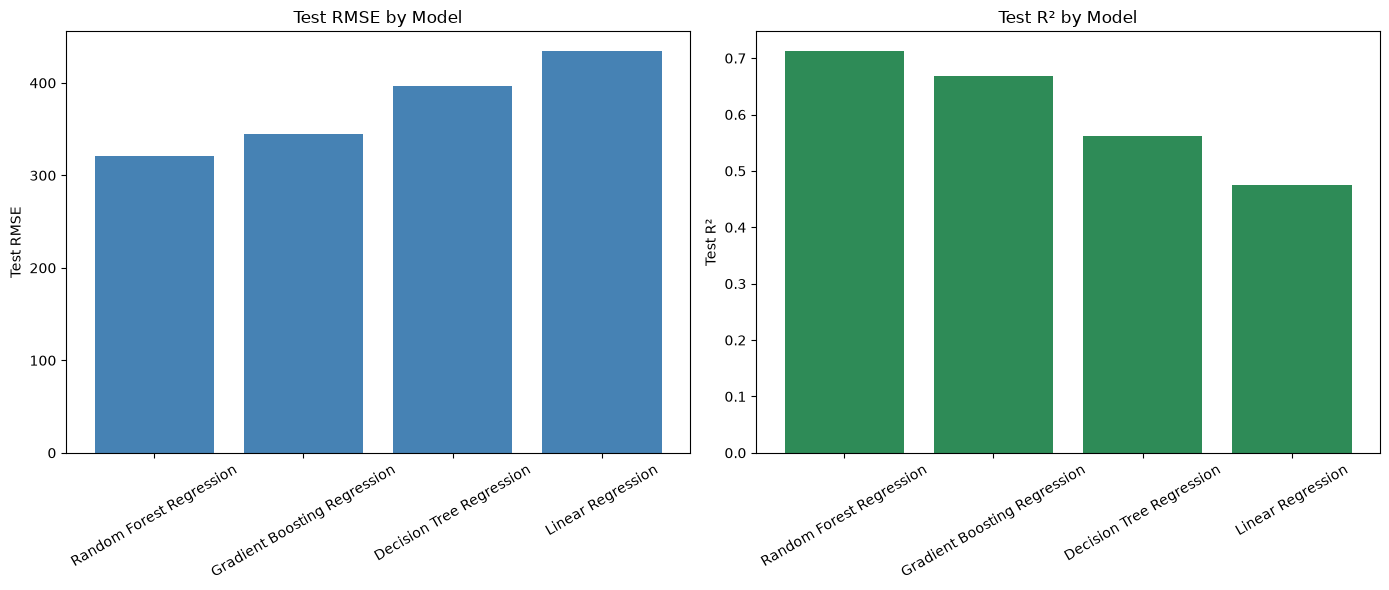

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(comparison_df["Model"], comparison_df["Test RMSE"], color="steelblue")
axes[0].set_title("Test RMSE by Model")
axes[0].set_ylabel("Test RMSE")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(comparison_df["Model"], comparison_df["Test R2"], color="seagreen")
axes[1].set_title("Test R² by Model")
axes[1].set_ylabel("Test R²")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Train vs Test R² (Overfitting Check)

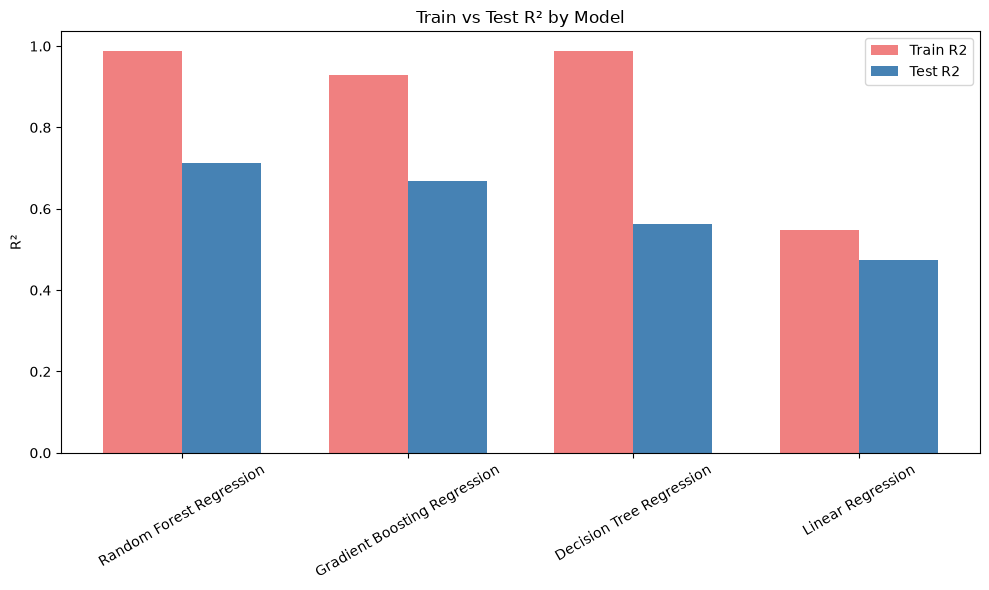

In [53]:
x = range(len(comparison_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], comparison_df["Train R2"], width, label="Train R2", color="lightcoral")
plt.bar([i + width/2 for i in x], comparison_df["Test R2"], width, label="Test R2", color="steelblue")
plt.xticks(list(x), comparison_df["Model"], rotation=30)
plt.ylabel("R²")
plt.title("Train vs Test R² by Model")
plt.legend()
plt.tight_layout()
plt.show()

## Save Best Model for Deployment Prototype

In [59]:
import joblib

model_lookup = {
    "Linear Regression": lr_final,
    "Decision Tree Regression": tree_final,
    "Random Forest Regression": rf_final,
    "Gradient Boosting Regression": gb_final
}

joblib.dump(model_lookup, "all_models.pkl", compress=6)   # ← only this line changed (added compress=6)
joblib.dump(comparison_df, "comparison_df.pkl")

print("\nModels saved:", list(model_lookup.keys()))
print("\nReal computed metrics:")
comparison_df


Models saved: ['Linear Regression', 'Decision Tree Regression', 'Random Forest Regression', 'Gradient Boosting Regression']

Real computed metrics:


,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Random Forest Regression,41.050,73.286,0.987,224.953,321.427,0.712
1,Gradient Boosting Regression,111.050,172.471,0.929,249.156,344.921,0.669
2,Decision Tree Regression,37.393,73.821,0.987,290.307,396.504,0.562
3,Linear Regression,325.586,433.837,0.549,324.433,434.082,0.475
